# From-Scratch HMM for Bull vs Bear Market Detection

_Generated: 2025-10-22T16:20:16.439705Z_

**Objective.** Detect latent **bull** and **bear** regimes in financial time series using a two-state Hidden Markov Model (HMM) implemented from first principles (NumPy only for inference and learning). We use diagonal-Gaussian emissions on engineered features (e.g., returns and volatility proxies), estimate parameters with **Baum–Welch (EM)** using scaled forward–backward, and visualize per-day **state posterior probabilities** and the **Viterbi** most likely regime path.

**Disclaimers.** This notebook is for research and education only—**not** financial advice. Historical regimes do not imply future performance.

## 0. Environment & Dependencies

We keep dependencies minimal. NumPy + Matplotlib for core work; Pandas for time series handling; yfinance for data download (optional).

In [1]:
import sys, platform, subprocess
def _sh(cmd):
    try:
        out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, text=True)
    except Exception as e:
        out = f"[command failed] {e}"
    print(out)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("In Colab:", "google.colab" in sys.modules)
print("\nNVIDIA SMI (if present):")
_sh("nvidia-smi || true")

!pip -q install --upgrade pip
!pip -q install numpy pandas matplotlib yfinance

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
In Colab: True

NVIDIA SMI (if present):
/bin/sh: 1: nvidia-smi: not found

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.9 MB/s eta 0:00:00


## 1. Imports, Seeding, and Plotting Defaults

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

np.set_printoptions(precision=4, suppress=True)
SEED = 123
rng = np.random.default_rng(SEED)
print("Seeded.")

Seeded.


## 2. Data Acquisition

Choose one of the following:
- **Option A**: Download daily OHLCV via `yfinance` by specifying a ticker and date range.
- **Option B**: Upload a CSV with at least a `Date` column and `Adj Close` (or `Close`).

In [7]:
# === Option A: yfinance ===
TICKER = "SPY"          # e.g., SPY, ^GSPC, QQQ, BTC-USD
START = "2005-01-01"
END   = None            # None means up to latest

if END is None:
    df = yf.download(TICKER, start=START, auto_adjust=True, progress=False)
else:
    df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)

df = df.rename_axis("Date").reset_index()
print("Downloaded rows:", len(df))
df.head(3)

Downloaded rows: 5235


Price,Date,Close,High,Low,Open,Volume
Ticker,,SPY,SPY,SPY,SPY,SPY
0,2005-01-03,81.847137,82.840460,81.574993,82.704386,55748000
1,2005-01-04,80.847015,82.010428,80.581676,81.955998,69167600
2,2005-01-05,80.289139,81.132782,80.282334,80.785798,65667300


In [4]:
# === Option B: CSV upload (uncomment to use) ===
# from google.colab import files  # type: ignore
# up = files.upload()
# import io
# name = list(up.keys())[0]
# df = pd.read_csv(io.BytesIO(up[name]))
# if "Date" in df.columns:
#     df["Date"] = pd.to_datetime(df["Date"])
# else:
#     raise ValueError("CSV must include a 'Date' column.")
# print("Uploaded rows:", len(df))
# df.head(3)

## 3. Feature Engineering

We compute **daily log returns** and a simple **volatility proxy** (e.g., rolling standard deviation of returns). You can extend with additional features (e.g., realized volatility, volume z-scores, macro signals).

In [15]:
# Ensure chronological order
df = df.sort_values(('Date','')).reset_index(drop=True)

# Pick the price column for your ticker (e.g., SPY)
ticker = 'SPY'
price_col = ('Adj Close', ticker) if ('Adj Close', ticker) in df.columns else ('Close', ticker)
if price_col not in df.columns:
    raise ValueError(f"Expected ('Adj Close','{ticker}') or ('Close','{ticker}') column.")

# Compute log returns and rolling volatility
df[('ret','')] = np.log1p(df[price_col].pct_change())
window = 20
df[('vol','')] = df[('ret','')].rolling(window, min_periods=window).std()

# Drop warmup NaNs — use tuple labels for MultiIndex columns
df = df.dropna(subset=[('ret',''), ('vol','')]).reset_index(drop=True)

# Display results
print(df[[('Date',''), price_col, ('ret',''), ('vol','')]].head())

Price        Date      Close       ret       vol
Ticker                   SPY                    
0      2005-02-01  80.901428  0.006327  0.006442
1      2005-02-02  81.146339  0.003023  0.005860
2      2005-02-03  80.935432 -0.002602  0.005660
3      2005-02-04  81.799484  0.010619  0.006025
4      2005-02-07  81.690666 -0.001331  0.006024


## 4. Standardization

Standardize features for numerical stability. We keep a simple (mean, std) scaler for later inversion if needed.

In [16]:
class StandardScalerNP:
    def __init__(self, eps=1e-12):
        self.mean_ = None
        self.std_ = None
        self.eps = eps
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_  = X.std(axis=0)
        self.std_  = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self
    def transform(self, X):
        return (X - self.mean_) / self.std_
    def fit_transform(self, X):
        return self.fit(X).transform(X)

X = df[["ret","vol"]].to_numpy().astype(float)
scaler = StandardScalerNP().fit(X)
Xs = scaler.transform(X)
T, D = Xs.shape
print("Feature matrix shape:", Xs.shape)

Feature matrix shape: (5215, 2)


## 5. Two-State HMM with Diagonal-Gaussian Emissions

We model regimes (bear/bull) as hidden states $z_t\in\{0,1\}$ with Markov transitions and diagonal-Gaussian emissions over features. Parameters: initial $\pi$, transition $A$, means $\mu_k\in\mathbb{R}^D$, variances $\sigma_k^2\in\mathbb{R}^D$ for each state $k$.

We implement **scaled forward–backward** and **Baum–Welch (EM)** from scratch for stable estimation.

### 5.1 HMM Implementation (from scratch)

In [17]:
import numpy as np

def normalize_rows(M, eps=1e-12):
    row_sums = M.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums < eps, 1.0, row_sums)
    return M / row_sums

def init_hmm_params(K, D, rng):
    A = rng.random((K, K)) + 1e-2
    A = normalize_rows(A)
    pi = np.ones(K) / K
    means = rng.normal(0.0, 0.5, size=(K, D))
    vars_ = np.ones((K, D)) * 0.5
    return pi, A, means, vars_

def log_diag_gaussian(x, mean, var, eps=1e-6):
    var = np.maximum(var, eps)
    D = x.shape[-1]
    logdet = np.sum(np.log(var))
    quad = np.sum((x - mean)**2 / var)
    return -0.5 * (logdet + quad + D*np.log(2*np.pi))

def emission_loglik_sequence(seq, means, vars_):
    T, D = seq.shape
    K = means.shape[0]
    B = np.empty((T, K), dtype=np.float64)
    for t in range(T):
        for k in range(K):
            B[t, k] = log_diag_gaussian(seq[t], means[k], vars_[k])
    return B

def forward_backward_scaled(logB, pi, A, eps=1e-12):
    T, K = logB.shape
    B = np.exp(logB - logB.max(axis=1, keepdims=True))
    alpha = np.zeros((T, K), dtype=np.float64)
    c = np.zeros(T, dtype=np.float64)
    alpha[0] = pi * B[0]
    c[0] = alpha[0].sum() + eps
    alpha[0] /= c[0]
    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ A) * B[t]
        c[t] = alpha[t].sum() + eps
        alpha[t] /= c[t]
    beta = np.zeros((T, K), dtype=np.float64)
    beta[-1] = 1.0 / c[-1]
    for t in range(T-2, -1, -1):
        beta[t] = (A @ (B[t+1] * beta[t+1]))
        beta[t] /= c[t]
    gamma = alpha * beta
    gamma /= gamma.sum(axis=1, keepdims=True)
    xi = np.zeros((T-1, K, K), dtype=np.float64)
    for t in range(T-1):
        z = (alpha[t][:,None] * A) * (B[t+1][None,:] * beta[t+1][None,:])
        s = z.sum() + eps
        xi[t] = z / s
    loglik = np.sum(np.log(c + eps)) + np.sum(logB.max(axis=1))
    return alpha, beta, gamma, xi, loglik

def baum_welch_diagonal_gaussian(seq, K=2, iters=100, tol=1e-4, min_var=1e-5, rng=np.random.default_rng(0), verbose=True):
    T, D = seq.shape
    pi, A, means, vars_ = init_hmm_params(K, D, rng)
    prev_ll = -np.inf
    ll_history = []
    for it in range(1, iters+1):
        logB = emission_loglik_sequence(seq, means, vars_)
        alpha, beta, gamma, xi, ll = forward_backward_scaled(logB, pi, A)
        # M-step
        pi = gamma[0] / gamma[0].sum()
        A = xi.sum(axis=0)
        A = normalize_rows(A + 1e-8)
        # Means
        new_means = np.zeros_like(means)
        gamma_den = gamma.sum(axis=0)  # (K,)
        for k in range(K):
            if gamma_den[k] < 1e-10:
                new_means[k] = means[k]
            else:
                new_means[k] = (gamma[:,k][:,None] * seq).sum(axis=0) / gamma_den[k]
        means = new_means
        # Variances
        new_vars = np.zeros_like(vars_)
        for k in range(K):
            if gamma_den[k] < 1e-10:
                new_vars[k] = vars_[k]
            else:
                diff = seq - means[k]
                new_vars[k] = (gamma[:,k][:,None] * (diff**2)).sum(axis=0) / gamma_den[k]
            new_vars[k] = np.maximum(new_vars[k], min_var)
        vars_ = new_vars
        ll_history.append(ll)
        if verbose and (it % 10 == 0 or it == 1):
            print(f"[EM] iter {it:03d}  loglik={ll:.3f}")
        if np.isfinite(prev_ll) and (ll - prev_ll) < tol:
            break
        prev_ll = ll
    return {"pi": pi, "A": A, "means": means, "vars": vars_, "ll_history": ll_history}

def viterbi(seq, model):
    pi, A, means, vars_ = model["pi"], model["A"], model["means"], model["vars"]
    T = seq.shape[0]; K = means.shape[0]
    logB = emission_loglik_sequence(seq, means, vars_)
    log_pi = np.log(pi + 1e-12)
    log_A = np.log(A + 1e-12)
    delta = np.zeros((T, K))
    psi = np.zeros((T, K), dtype=int)
    delta[0] = log_pi + logB[0]
    for t in range(1, T):
        for k in range(K):
            prev = delta[t-1] + log_A[:,k]
            psi[t, k] = int(np.argmax(prev))
            delta[t, k] = prev[psi[t,k]] + logB[t, k]
    path = np.zeros(T, dtype=int)
    path[-1] = int(np.argmax(delta[-1]))
    for t in range(T-2, -1, -1):
        path[t] = psi[t+1, path[t+1]]
    return path

## 6. Fit Two-State HMM (Bull vs Bear)

In [18]:
K = 2
model = baum_welch_diagonal_gaussian(Xs, K=K, iters=200, tol=1e-5, rng=rng, verbose=True)
print("pi:", model["pi"])
print("A:\n", model["A"])
print("means:\n", model["means"])
print("vars:\n", model["vars"])

[EM] iter 001  loglik=-17021.605
[EM] iter 010  loglik=-9578.442
[EM] iter 020  loglik=-9569.443
[EM] iter 030  loglik=-9569.131
pi: [1. 0.]
A:
 [[0.9913 0.0087]
 [0.0176 0.9824]]
means:
 [[ 0.025  -0.466 ]
 [-0.0506  0.9437]]
vars:
 [[0.3106 0.0735]
 [2.3922 1.5458]]


## 7. Posterior Probabilities, Viterbi Path, and Regime Labeling

We compute per-time $\gamma_t(k)=p(z_t=k\mid x_{1:T})$ and the Viterbi most likely path. To label states as **bull** vs **bear**, we inspect the **mean standardized return** per state (or mean raw return). The state with higher mean return is labeled **bull**.

In [19]:
# Posterior (gamma) over time
logB = emission_loglik_sequence(Xs, model["means"], model["vars"])
alpha, beta, gamma, xi, ll = forward_backward_scaled(logB, model["pi"], model["A"])
path = viterbi(Xs, model)

# Map states to bull/bear via mean raw returns grouped by most likely state
state_means = {}
for k in range(K):
    idx = np.where(path == k)[0]
    state_means[k] = df["ret"].iloc[idx].mean() if len(idx) > 0 else -np.inf

order = np.argsort([state_means[k] for k in range(K)])
bear_state = int(order[0])
bull_state = int(order[-1])
print(f"Assigned labels: bear={bear_state}, bull={bull_state}")

Assigned labels: bear=1, bull=0


## 8. Visualizations

We visualize the adjusted close, posterior probabilities for the **bull** state, and the Viterbi-regime segmentations. We avoid specifying colors explicitly (default Matplotlib palette).

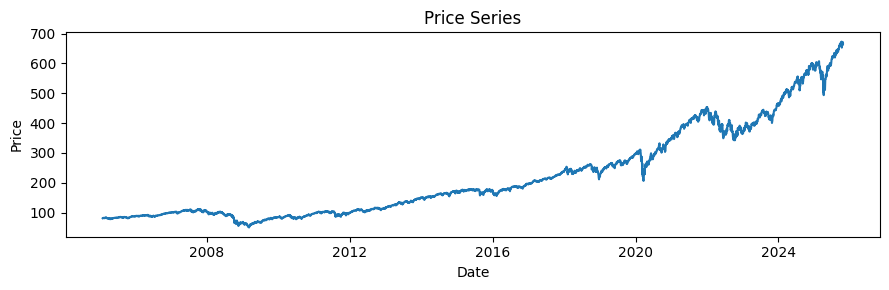

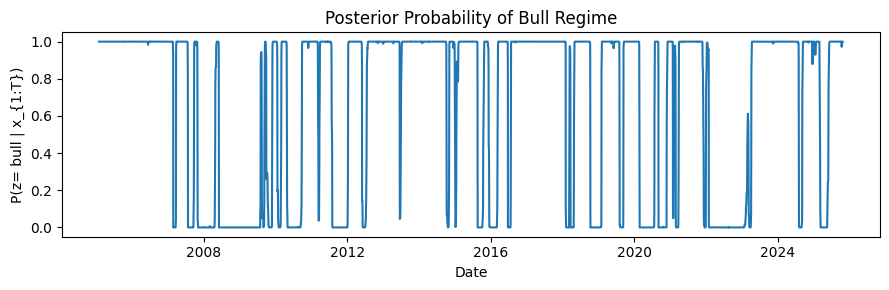

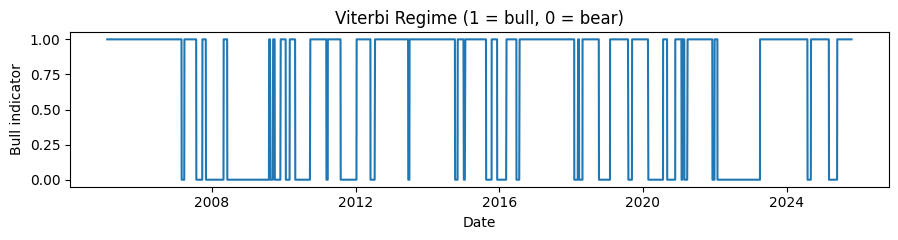

In [20]:
dates = pd.to_datetime(df["Date"]).to_numpy()
price = df["Adj Close"] if "Adj Close" in df.columns else df["Close"]

# 8.1 Price
fig = plt.figure(figsize=(9,3))
plt.plot(dates, price.values)
plt.title(f"Price Series")
plt.xlabel("Date"); plt.ylabel("Price")
plt.tight_layout()
plt.show()

# 8.2 Posterior probability of bull state
fig = plt.figure(figsize=(9,3))
plt.plot(dates, gamma[:, bull_state])
plt.title("Posterior Probability of Bull Regime")
plt.xlabel("Date"); plt.ylabel("P(z= bull | x_{1:T})")
plt.tight_layout()
plt.show()

# 8.3 Viterbi regime indicator (0/1 for bull)
v_bull = (path == bull_state).astype(int)
fig = plt.figure(figsize=(9,2.5))
plt.plot(dates, v_bull)
plt.title("Viterbi Regime (1 = bull, 0 = bear)")
plt.xlabel("Date"); plt.ylabel("Bull indicator")
plt.tight_layout()
plt.show()

## 9. Simple Regime-Based Strategy (Optional)

Toy strategy: **invest when bull**, otherwise **cash** (no shorting). We compare cumulative returns of this strategy to buy-and-hold. This is only illustrative.

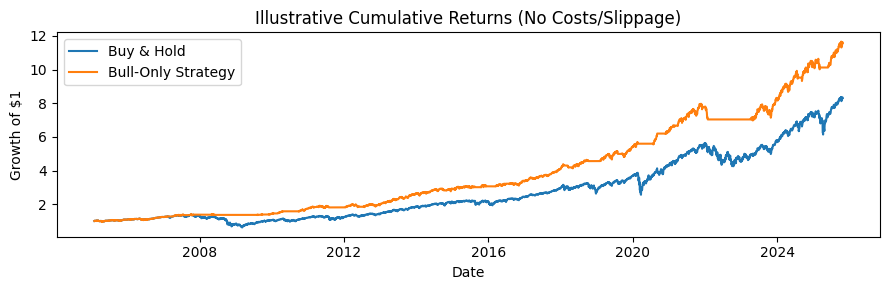

In [21]:
rets = df["ret"].to_numpy()
bh_cum = np.exp(np.cumsum(rets))
strat_rets = rets * (v_bull[:-1].tolist() + [v_bull[-1]])
strat_cum = np.exp(np.cumsum(strat_rets))

fig = plt.figure(figsize=(9,3))
plt.plot(dates, bh_cum, label="Buy & Hold")
plt.plot(dates, strat_cum, label="Bull-Only Strategy")
plt.title("Illustrative Cumulative Returns (No Costs/Slippage)")
plt.xlabel("Date"); plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

## 10. EM Convergence Diagnostics

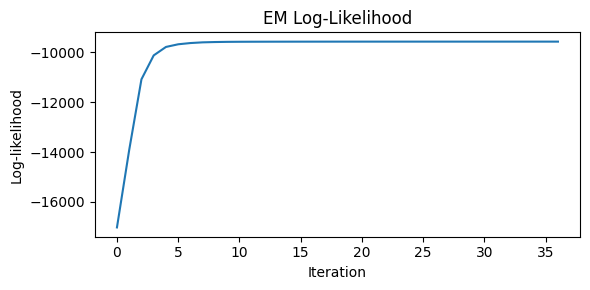

In [22]:
fig = plt.figure(figsize=(6,3))
plt.plot(model["ll_history"])
plt.title("EM Log-Likelihood")
plt.xlabel("Iteration"); plt.ylabel("Log-likelihood")
plt.tight_layout()
plt.show()

## 11. Save Artifacts & Download

Persist learned parameters, posteriors, Viterbi path, and plots. Use the helper below to download a ZIP in Colab.

In [23]:
import os, json
os.makedirs("artifacts", exist_ok=True)

# Parameters and results
np.savez("artifacts/hmm_params_and_results.npz",
         pi=model["pi"], A=model["A"], means=model["means"], vars=model["vars"],
         gamma=gamma, path=path, bull_state=np.array([bull_state]), bear_state=np.array([bear_state]))

# Metrics summary
metrics = {
    "final_loglik": float(model["ll_history"][-1]) if len(model["ll_history"])>0 else None,
    "bull_state": int(bull_state),
    "bear_state": int(bear_state),
    "buy_hold_growth": float(np.exp(np.sum(df["ret"]))),
    "strategy_growth": float(np.exp(np.sum(rets * (v_bull[:-1].tolist() + [v_bull[-1]]))))
}
with open("artifacts/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved artifacts:", os.listdir("artifacts"))

Saved artifacts: ['metrics.json', 'hmm_params_and_results.npz']


In [24]:
# Colab download helper
import shutil
from pathlib import Path
try:
    from google.colab import files  # type: ignore
    if Path('artifacts').exists():
        shutil.make_archive('artifacts', 'zip', 'artifacts')
        files.download('artifacts.zip')
    else:
        print('No artifacts folder found.')
except Exception as e:
    print('Colab download helper not available in this environment:', e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Extensions & Research Ideas

- **Feature set**: realized volatility, overnight returns, macro factors, term structure proxies.
- **Regime priors**: constrain transitions for persistence (e.g., sticky HMM via Dirichlet priors).
- **Emission richness**: full-covariance Gaussians or Gaussian mixtures per state.
- **Multivariate assets**: joint HMM over a bundle of assets or spread portfolios.
- **Online filtering**: real-time updates with fixed parameters (fit on a training window, evaluate out of sample).
- **Transaction costs**: realistic backtests with slippage, costs, and rebalancing rules.